# The power stage

*The gate drivers armed and driven: dead time read from the silicon, a counted hold, the six gates in one snapshot, a burst over the currents, and what switching costs from the SPICE-traced constants.*

**Abstract.** Six FETs behind three 2EDL8034 drivers switch at 50 kHz, and the only thing between the two FETs of a leg is TIM1's dead time: the driver has no interlock of its own. This notebook drives the stage through `device.gates`, the one arming policy, and `device.gate_drivers`, the board's raw ops, on the stand-in and on a board with the knob flipped. It reads the dead time off BDTR rather than the `.ioc`, arms through the three refusals that stand before MOE, holds a compare triple for a counted 500 periods, reads the six gates and the counter in one snapshot twelve times, and captures 300 records at the loop's full rate with the pins beside the currents. The last three sections need no board: `coaxial.inverter` carries the constants traced from the schematic and the LTSpice models, and from them come the output charge, the switch-node ring, the blanking margin, the dead-time knee and the conduction loss over the 23 to 63 V link sweep. Headline numbers: DTG 19 reads 79 ns where the calibration record's DTG 8 is 33.7 ns; 500 periods is 10.000 ms where a link-timed hold measured 93 to 108 ms; no snapshot shows a leg with both FETs on; the burst drops nothing; the blanking margin at 63 V is 152.7 ns; of the camera's 1.20 W of no-load switching, half on the bridge and half on the supply corner, a 0.36 W Coss term and 0.34 W of gate charge through the buck are what the arithmetic carries. What a reader takes to the bench: the dead time is read every time and never trusted once, a hold's length is the board's and not the link's, and every loss figure here is arithmetic until a scope on the switch node replaces Q_RING.

## 1 Setup

In [1]:
SIMULATED = True          # False, and PORT, at the bench
PORT = 'COM4'

In [2]:
from coaxial import Coaxial63100

device = Coaxial63100(port=PORT, simulated_device=SIMULATED).open()
print(device)

<Coaxial63100 Simulated SIMULATED>


## 2 The dead time, read from the silicon

`device.gates` is the arming policy, one of it. `check()` re-reads BDTR DTG every time and refuses a stage with no dead time: a `.ioc` regeneration, a CubeMX mode bound to the wrong channel or a stray BDTR write all land in that register, and none announce themselves. DTG counts are 4.21 ns apart at 237.5 MHz. The `.ioc` holds DTG 19 until the calibration record loads; the record's 30 ns rounds up to DTG 8 = 33.7 ns, trimmed against the bench supply's over-current protection after 7 counts = 29.5 ns tripped it (FINDINGS, 2026-08-29). The firmware floors the register at 20 ns; DTG 127 = 535 ns is the ceiling. HARDWARE.md states the tension between the 80 ns fitted against about 65 ns of worst-corner overlap and the 33.7 ns the record trims to; here is what the stage answers.

In [3]:
stage = device.gates
dead = stage.dead_time()
check = stage.check()
print('dead time  :', dead)
print('check      :', {k: check[k] for k in ('deadtime', 'deadtime_ns', 'deadtime_floor',
                                            'period', 'gate_shorts', 'pwm_enabled', 'fault')})
DTS_NS = 1e3 / 237.5                       # one DTG count at 237.5 MHz
print()
print('  DTG      ns   which')
for counts, which in ((check['deadtime_floor'], 'the firmware floor, 20 ns rounded up'),
                      (7, 'tripped the supply OCP, 2026-08-29'),
                      (8, "the record's 30 ns, rounded up"),
                      (19, "the .ioc, until the record loads"),
                      (127, 'the ceiling of the register')):
    print('  %3d   %5.1f   %s' % (counts, counts * DTS_NS, which))
print()
print('the stage reads DTG %d = %d ns, %.1fx the record\'s 33.7 ns'
      % (check['deadtime'], check['deadtime_ns'], check['deadtime_ns'] / 33.7))

dead time  : {'nanoseconds': 79, 'skew': 0, 'floor': 5}
check      : {'deadtime': 19, 'deadtime_ns': 79, 'deadtime_floor': 5, 'period': 2376, 'gate_shorts': (), 'pwm_enabled': False, 'fault': True}

  DTG      ns   which
    5    21.1   the firmware floor, 20 ns rounded up
    7    29.5   tripped the supply OCP, 2026-08-29
    8    33.7   the record's 30 ns, rounded up
   19    80.0   the .ioc, until the record loads
  127   534.7   the ceiling of the register

the stage reads DTG 19 = 79 ns, 2.3x the record's 33.7 ns


The stand-in answers the `.ioc`'s DTG 19, 79.99 ns truncated to 79, with no record loaded; a board that has loaded its record answers DTG 8. Either way `check()` read it now, and the number it prints is the one the FETs get.

## 3 Arming, and what refuses first

Three things stand between a duty write and the FETs, in order. MOE: a compare write before `arm()` is refused by the board. The interlock: the schematic wants the charge pump pumped and the level detector tripped, Cinj and Clevel at 3 V, before the gate drive is armed; the unmodified bench board reads 0.77 V and 0.06 V, so `ignore_interlock=True` is what arms it. The break: PE15 is latched low until the STO chain releases, and clearing the latch does nothing while it stays low, so `bypass_sto=True` drops BKE instead. Both flags are decisions, which is why neither is silent. The interlock reads through the converters, whose reference AFE_ON powers (invariant 9): `daq.enable()` takes this session's hold on the rail, and the close releases it.

In [4]:
import textwrap

from coaxial.errors import RigError

daq = device.daq
daq.enable()
for name, volts, ok, want in stage.interlock():
    print('%-8s %-8s ok=%-5s want=%s' % (name, '-' if volts is None else '%.2f V' % volts, ok, want))
gd = device.gate_drivers
refused = []
for what, call in (('a duty before arm', lambda: gd.duty((10, 0, 0))),
                   ('arm() on the interlock', lambda: stage.arm()),
                   ('arm() past the interlock, break latched',
                    lambda: stage.arm(ignore_interlock=True))):
    try:
        call()
        print('%-42s took' % what)
    except RigError as e:
        refused.append(what)
        print(textwrap.fill('%s REFUSED: %s' % (what, e), width=96,
                            subsequent_indent='    '))
armed = stage.arm(bypass_sto=True, ignore_interlock=True)
print()
print('armed: pwm_enabled %s  fault %s  break_bypassed %s  duty %s'
      % (armed['pwm_enabled'], armed['fault'], armed['break_bypassed'], armed['duty']))

AFE_ON   -        ok=True  want=None
Cinj     0.90 V   ok=False want=3.0
Clevel   0.05 V   ok=False want=3.0
a duty before arm REFUSED: the gate drivers are not enabled (simulated)
arm() on the interlock REFUSED: the arming interlock is not satisfied: Cinj 0.90 V, wants 3.0,
    Clevel 0.05 V, wants 3.0. The schematic wants the charge pump up and the level detector
    tripped before the gate drive is armed. Pass ignore_interlock=True to arm anyway, which is
    what an unmodified bench board needs
arm() past the interlock, break latched REFUSED: the board refused to enable the gate drivers -
    check fault, and whether the STO chain has released (simulated)

armed: pwm_enabled True  fault False  break_bypassed True  duty (0, 0, 0)


## 4 A counted hold

A duty is ticks against `period - 1`, all three compares in one write or none. A compare write lands in about 15 ms, some 750 PWM periods, so a hold timed by the link is the link's: 100 ms asked for measured 93 to 108 ms at the FETs (FINDINGS). Since MINOR 8 op 2 takes a period count and the update ISR zeroes the compares when it runs out: 500 periods is 10.000 ms at 50 kHz whatever the link does. The snapshot straight after the write shows the count running; the second read is 50 ms later, past the hold by three round trips, so it has to show zero left and the compares zeroed - the reason for the sleep.

In [5]:
import time

period = armed['period']
tenth = (period - 1) // 10
gd.duty((tenth, 0, 0), periods=500)
snap = gd.state()
for key in ('period', 'deadtime', 'deadtime_ns', 'duty', 'requested_ticks', 'pins',
            'pins_at', 'periods_left', 'updates', 'overruns', 'keepalive',
            'worst_gap_cycles', 'gate_shorts', 'break_bypassed', 'dcbus_raw', 'ntc_raw'):
    print('%-16s %s' % (key, snap.get(key, 'not in this reply')))
time.sleep(0.05)
after = gd.state()
print()
print('asked %d of %d ticks = %.1f %% for 500 periods = %.3f ms'
      % (tenth, period - 1, 100.0 * tenth / (period - 1), 500.0 / 50e3 * 1e3))
print('periods_left straight after the write %d, 50 ms later %d; duty now %s'
      % (snap['periods_left'], after['periods_left'], after['duty']))

period           2376
deadtime         19
deadtime_ns      79
duty             (237, 0, 0)
requested_ticks  (237.0, 0.0, 0.0)
pins             {'UL': True, 'UH': False, 'VL': True, 'VH': False, 'WL': True, 'WH': False}
pins_at          1326
periods_left     499
updates          0
overruns         0
keepalive        1284000
worst_gap_cycles 24700
gate_shorts      ()
break_bypassed   True
dcbus_raw        not in this reply
ntc_raw          not in this reply

asked 237 of 2375 ticks = 10.0 % for 500 periods = 10.000 ms
periods_left straight after the write 499, 50 ms later 0; duty now (0, 0, 0)


## 5 The six gates in one snapshot

`pins` is one IDR load with TIM1->CNT beside it as `pins_at`. Six separate reads at 50 kHz could straddle an edge and show a leg with both FETs on, the one state dead time exists to prevent; one load cannot. It is one instant, not a duty: repeated reads land at different counts and walk the period, and averaging them is only honest while `pins_at` spreads - with the sync armed CNT lands in the same band every time, measured 89.5 % high at 50 % duty. `gate_shorts` is the board's own measurement: it drives one gate pin and watches the other sink through its pull-down of about 40 k; with the W pair joined the neighbour followed within 76 ns (FINDINGS). It reads no legs while armed, because the probe needs the pins.

In [6]:
gd.duty((tenth, tenth, tenth))
snapshots = [gd.state() for _ in range(12)]
print('  CNT   UL UH   VL VH   WL WH   both on?')
for s in snapshots:
    p = s['pins']
    both = [leg for leg in ('U', 'V', 'W') if p[leg + 'L'] and p[leg + 'H']]
    print('%5d %5d%3d%5d%3d%5d%3d   %s'
          % (s['pins_at'], p['UL'], p['UH'], p['VL'], p['VH'], p['WL'], p['WH'],
             ','.join(both) if both else 'no'))
walked = sorted(s['pins_at'] for s in snapshots)
both_on = sum(1 for s in snapshots for leg in ('U', 'V', 'W')
              if s['pins'][leg + 'L'] and s['pins'][leg + 'H'])
high = sum(1 for s in snapshots for leg in ('U', 'V', 'W') if s['pins'][leg + 'H'])
print()
print('%d reads, CNT %d to %d of %d; high side on in %d of %d leg samples (%.1f %% asked); '
      'both FETs on in %d' % (len(snapshots), walked[0], walked[-1], snap['period'],
                              high, 3 * len(snapshots), 100.0 * tenth / (period - 1), both_on))

  CNT   UL UH   VL VH   WL WH   both on?
  184     0  1    0  1    0  1   no
  801     1  0    1  0    1  0   no
 1418     1  0    1  0    1  0   no
 2035     1  0    1  0    1  0   no
  276     1  0    1  0    1  0   no
  893     1  0    1  0    1  0   no
 1510     1  0    1  0    1  0   no
 2127     1  0    1  0    1  0   no
  368     1  0    1  0    1  0   no
  985     1  0    1  0    1  0   no
 1602     1  0    1  0    1  0   no
 2219     1  0    1  0    1  0   no

12 reads, CNT 184 to 2219 of 2376; high side on in 3 of 36 leg samples (10.0 % asked); both FETs on in 0


## 6 A burst over the currents

A capture is the opposite of a stream: nothing is decimated, every sweep the loop manages becomes a record until the ring is full, and only then does the link get involved, so `dropped` is zero by construction. The pins ride the same records as the currents, so every point on both is one window. The clock is tied to the host first so the index is seconds; the phase sense is tared with all three legs at the same duty, which is no phase current - measured 2026-08-27 at every duty from 1 to 100 %. What is left after the tare is the sense chain's noise, read against the floor measured on the board.

tare: {'Phase U': 1413, 'Phase V': -7997, 'Phase W': 395}


300 records, dropped 0, 0.702 s of window; dt 47 us to 2516 us; the ring holds 16990
Phase U (A)  mean -0.094 A  rms 0.232 A
Phase V (A)  mean -0.227 A  rms 0.217 A
Phase W (A)  mean -0.203 A  rms 0.206 A
measured floor on the board, A rms: (0.35, 0.41)
gate columns, mean duty: PWMUL 0.000  PWMUH 0.000  PWMVL 0.000  PWMVH 0.000  PWMWL 0.000  PWMWH 0.000


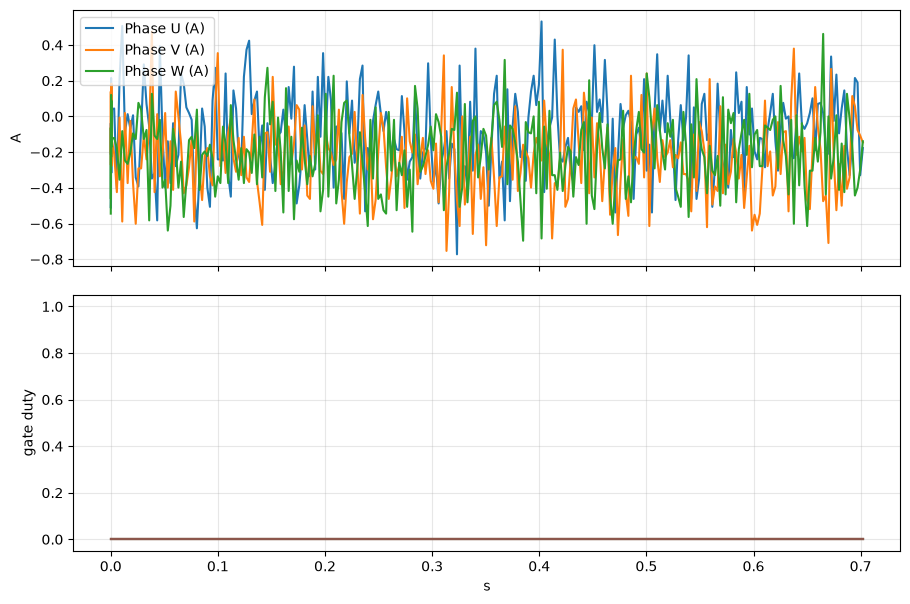

In [7]:
from coaxial import inverter
from coaxial.figures import figure, show

device.set_time_from_pc()
print('tare:', device.calibration.tare('phaseU', 'phaseV', 'phaseW'))
burst = daq.capture('phaseU', 'phaseV', 'phaseW', records=300)
shape = daq.state()
df = daq.frame(burst, index='elapsed', scaled=True)
amps = [c for c in df.columns if c.endswith('(A)')]
gates = [c for c in df.columns if c.startswith('TIM1_CH')]
spans = [r.dt for r in burst if r.dt]
print('%d records, dropped %d, %.3f s of window; dt %.0f us to %.0f us; the ring holds %d'
      % (len(burst), shape['dropped'], df.index[-1], min(spans) * 1e6, max(spans) * 1e6,
         shape['capacity']))
noise = df[amps].std()
for column in amps:
    print('%-12s mean %+.3f A  rms %.3f A' % (column, df[column].mean(), noise[column]))
print('measured floor on the board, A rms: %s' % (inverter.NOISE_A,))
print('gate columns, mean duty:',
      '  '.join('%s %.3f' % (c.split('/')[1], df[c].mean()) for c in gates))
fig, (top, bottom) = figure(rows=2, sharex=True)
for column in amps:
    top.plot(df.index, df[column], label=column)
top.set_ylabel('A')
top.legend(loc='upper left')
for column in gates:
    bottom.plot(df.index, df[column])
bottom.set_ylabel('gate duty')
bottom.set_ylim(-0.05, 1.05)
bottom.set_xlabel('s')
show(fig)

On the board the six gate columns' means are the duties asked for, since the sync is not armed and CNT spreads over the period. The stand-in's gate fields follow the drive's modulation and not a raw compare write, so they read zero here; that is the one thing in this window the bench sees and the stand-in cannot show. The `dt` spread is the stand-in pacing its stamps against the reader's wall, floored at the sweep cost; on the board the stamps are the loop's own sweep period, which a finite run measures and no constant states. The stage is put back before the device is closed: zero duty, then MOE clear and the break input restored.

In [8]:
gd.duty((0, 0, 0))
released = stage.disarm()
print('pwm_enabled', released['pwm_enabled'], ' break_bypassed', released['break_bypassed'],
      ' duty', released['duty'])

pwm_enabled False  break_bypassed False  duty (0, 0, 0)


## 7 What switching costs: the constants

This section and the two after it need no board. `coaxial.inverter` carries the stage's numbers in one importable place: FSW, the dead time, the FET's junction law (CJO, M, VJ from the vendor VDMOS model in `half_bridge.asc`), the power loop inductance, the shunt and the sense chain. None is a measurement on this board unless its comment says which, and the conclusions sort them by provenance. RDS_ON is the datasheet's typical, 1.8 mohm against 2.1 max, because the LTSpice model this tree traces is the typical one.

In [9]:
print('FSW %.0f Hz  TS %.1f us  T_DEAD %.1f ns (DTG 8)  T_DEAD_SIM %.1f ns  T_MIN_PULSE %.0f ns'
      % (inverter.FSW, inverter.TS * 1e6, inverter.T_DEAD * 1e9,
         inverter.T_DEAD_SIM * 1e9, inverter.T_MIN_PULSE * 1e9))
print('RDS_ON %.1f mohm  RTH_JC %.2f K/W  SHUNT %.1f mohm  L_LOOP %.1f nH  Q_RING %.1f (assumed)'
      % (inverter.RDS_ON * 1e3, inverter.RTH_JC, inverter.SHUNT * 1e3,
         inverter.L_LOOP * 1e9, inverter.Q_RING))
print('CJO %.1f nF  M %.2f  VJ %.2f  QG %.0f nC  V_FRAC %.2f'
      % (inverter.CJO * 1e9, inverter.M, inverter.VJ, inverter.QG * 1e9, inverter.V_FRAC))
print('AFE %.3f V/A, delay %.0f ns, %.1f mA per count, noise %s A rms measured'
      % (inverter.AFE_V_PER_A, inverter.AFE_DELAY * 1e9, inverter.AFE_A_PER_COUNT * 1e3,
         inverter.NOISE_A))

FSW 50000 Hz  TS 20.0 us  T_DEAD 33.7 ns (DTG 8)  T_DEAD_SIM 65.4 ns  T_MIN_PULSE 76 ns
RDS_ON 1.8 mohm  RTH_JC 0.69 K/W  SHUNT 3.5 mohm  L_LOOP 4.0 nH  Q_RING 1.0 (assumed)
CJO 15.6 nF  M 0.45  VJ 0.70  QG 81 nC  V_FRAC 0.95
AFE 0.016 V/A, delay 60 ns, 3.2 mA per count, noise (0.35, 0.41) A rms measured


Coss and Qoss over the link sweep, and the stored energy `E_oss = integral of v C(v) dv`: the capacitive part of a hard switched edge, dissipated once per turn-on per switch. Multiplied by FSW it is watts per switch; six switches carry it on the bridge.

 vdc   Coss nF   Qoss nC   E_oss uJ   P_coss W/switch   x6 W
   23      3.20     117.9      1.071      0.054      0.321
   33      2.73     147.4      1.891      0.095      0.567
   43      2.43     173.0      2.865      0.143      0.860
   53      2.21     196.2      3.974      0.199      1.192
   63      2.05     217.5      5.207      0.260      1.562


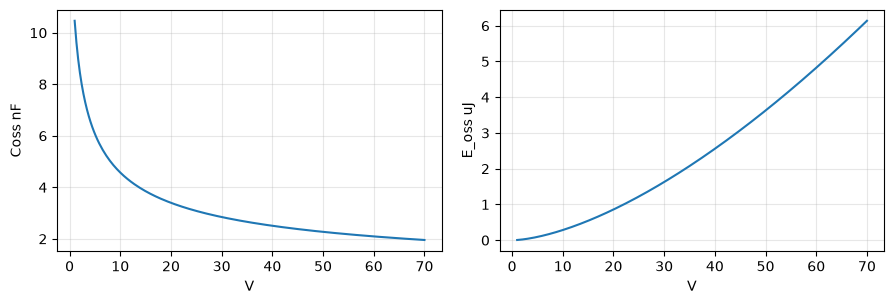

In [10]:
import numpy as np

VDC = (23.0, 33.0, 43.0, 53.0, 63.0)

def e_oss(v, steps=2000):
    grid = np.linspace(0.0, v, steps)
    return np.trapezoid(grid * inverter.coss(grid), grid)

print(' vdc   Coss nF   Qoss nC   E_oss uJ   P_coss W/switch   x6 W')
for vdc in VDC:
    e = e_oss(vdc)
    print('%5.0f   %7.2f   %7.1f   %8.3f   %8.3f   %8.3f'
          % (vdc, inverter.coss(vdc) * 1e9, inverter.qoss(vdc) * 1e9, e * 1e6,
             e * inverter.FSW, 6.0 * e * inverter.FSW))
volts = np.linspace(1.0, 70.0, 200)
fig, (left, right) = figure(rows=1, cols=2)
left.plot(volts, inverter.coss(volts) * 1e9)
left.set_xlabel('V')
left.set_ylabel('Coss nF')
right.plot(volts, [e_oss(v) * 1e6 for v in volts])
right.set_xlabel('V')
right.set_ylabel('E_oss uJ')
show(fig)

## 8 The ring, the blanking margin and the dead-time knee

`ring()` gives the switch node's frequency, decay and impedance from L_LOOP against both FETs' Coss; with Q_RING assumed, `tau_s` and the 1 % settling are design figures. `blanking()` is what is left for the current sample at the deepest duty the modulator allows: a quarter of the unused (1 - V_FRAC) window, minus the settling and the sense chain's 60 ns; positive means the sample lands on settled current. `dead_time_volts` is the mean voltage error at full current; `knee_amps`, 2 Qoss / t_dead, is the current that just slews the node across the link in the dead time - below it the output charge soft-switches the error away, the tanh knee the compensation table and the motor model share. `dt_table` samples that curve every half knee, eight points held past the last: record ids 34 to 42. The last lines evaluate the same at the dead time the stage read in section 2.

In [11]:
print(' vdc   f_ring MHz   tau ns   settle ns   Z ohm   blanking ns   V_dt V   knee A')
for vdc in VDC:
    r = inverter.ring(vdc)
    print('%5.0f   %9.1f   %6.2f   %8.1f   %6.2f   %10.1f   %6.3f   %6.2f'
          % (vdc, r['f_hz'] / 1e6, r['tau_s'] * 1e9, r['settle_s'] * 1e9, r['z_ohm'],
             inverter.blanking(vdc) * 1e9, inverter.dead_time_volts(vdc), inverter.knee_amps(vdc)))
step, table = inverter.dt_table(43.0)
print('43 V table: step %.2f A, volts %s' % (step, [round(v, 3) for v in table]))
print()
read_ns = check['deadtime_ns']
print('  t_dead ns   which                 V_dt @43 V   knee @43 V   V_dt @63 V   knee @63 V')
for t_dead, which in ((inverter.T_DEAD, 'the record, DTG 8'),
                      (inverter.T_DEAD_SIM, 'the simulation corner'),
                      (read_ns * 1e-9, 'the stage read, DTG %d' % check['deadtime'])):
    print('  %9.1f   %-20s   %8.3f   %8.2f     %8.3f   %8.2f'
          % (t_dead * 1e9, which, inverter.dead_time_volts(43.0, t_dead),
             inverter.knee_amps(43.0, t_dead), inverter.dead_time_volts(63.0, t_dead),
             inverter.knee_amps(63.0, t_dead)))

 vdc   f_ring MHz   tau ns   settle ns   Z ohm   blanking ns   V_dt V   knee A
   23        31.5    10.12       46.6     0.79        143.4    0.039     7.00
   33        34.1     9.34       43.0     0.86        147.0    0.056     8.74
   43        36.1     8.81       40.6     0.91        149.4    0.072    10.27
   53        37.8     8.41       38.8     0.95        151.2    0.089    11.64
   63        39.3     8.10       37.3     0.99        152.7    0.106    12.91
43 V table: step 5.13 A, volts [0.0, 0.033, 0.055, 0.066, 0.07, 0.071, 0.072, 0.072]

  t_dead ns   which                 V_dt @43 V   knee @43 V   V_dt @63 V   knee @63 V
       33.7   the record, DTG 8         0.072      10.27        0.106      12.91
       65.4   the simulation corner      0.141       5.29        0.206       6.65
       79.0   the stage read, DTG 19      0.170       4.38        0.249       5.51


## 9 Conduction, and the measured switching figure

Conduction is `I^2 (RDS_ON + SHUNT)` per phase, RDS_ON at 25 C; the shunt is 3.5 mohm against the FET's 1.8, which is why it binds the thermal envelope and not the FET. The one switching figure measured on this board is the camera campaign's: 1.20 W for three legs at 50 % on 24.6 V, the switching state less the passive one, roughly half on the supply corner - gate charge comes out of the +15V7 buck - and half on the bridge. `coaxial.thermal.POWER_SWITCHING` is the whole board's power per node in that state, the drivers' entries being the bridge's half. Below, the Coss term and the gate charge sit beside the two halves, and the E_oss ratio beside the law the thermal core scales that 1.20 W with.

In [12]:
from coaxial import thermal

print('  I A   conduction W/phase')
for amps_rms in (1.0, 5.0, 20.0, 50.0, 100.0):
    print('%5.0f   %8.2f' % (amps_rms, amps_rms * amps_rms * (inverter.RDS_ON + inverter.SHUNT)))
bridge = sum(thermal.POWER_SWITCHING[n] for n in thermal.DRIVERS)
whole = sum(thermal.POWER_SWITCHING.values())
coss_w = 6.0 * e_oss(24.6) * inverter.FSW
gate_w = 6.0 * inverter.QG * 12.0 * inverter.FSW
print()
print('camera, three legs 50 %% at 24.6 V: %.2f W switching increment, %.2f W of it on the bridge; '
      'the board as a whole %.2f W in that state' % (2.0 * bridge, bridge, whole))
print('Coss term, six switches at 24.6 V:  %.3f W = %.0f %% of the bridge half'
      % (coss_w, 100.0 * coss_w / bridge))
print('gate charge, 6 x 81 nC x 12 V x FSW: %.3f W at the gates, %.3f W from a buck at 85 %%'
      % (gate_w, gate_w / 0.85))
print('E_oss(63 V) / E_oss(24.6 V) = %.2f, the law the thermal core scales 1.20 W by'
      % (e_oss(63.0) / e_oss(24.6)))

  I A   conduction W/phase
    1       0.01
    5       0.13
   20       2.12
   50      13.25
  100      53.00

camera, three legs 50 % at 24.6 V: 1.20 W switching increment, 0.60 W of it on the bridge; the board as a whole 2.40 W in that state
Coss term, six switches at 24.6 V:  0.357 W = 60 % of the bridge half
gate charge, 6 x 81 nC x 12 V x FSW: 0.292 W at the gates, 0.343 W from a buck at 85 %
E_oss(63 V) / E_oss(24.6 V) = 4.37, the law the thermal core scales 1.20 W by


In [13]:
device.close()
print(device)

<Coaxial63100 Simulated SIMULATED>


## 10 Conclusions

In [14]:
print('1. period       %d ticks = %.1f kHz centre-aligned'
      % (snap['period'], 237.5e6 / (2.0 * (snap['period'] - 1)) / 1e3))
print('   dead time    the stage read DTG %d = %d ns; floor DTG %d = %.1f ns; '
      'the record trims to DTG 8 = %.1f ns'
      % (check['deadtime'], check['deadtime_ns'], check['deadtime_floor'],
         check['deadtime_floor'] * DTS_NS, inverter.T_DEAD * 1e9))
print('2. arming       %d refusals before MOE, in the board\'s words; armed with the break '
      'bypassed and the interlock ignored' % len(refused))
print('3. counted hold %d of %d ticks = %.1f %%, 500 periods = %.3f ms; periods_left %d then %d, '
      'compares %s' % (tenth, snap['period'] - 1, 100.0 * tenth / (snap['period'] - 1),
                       500.0 / 50e3 * 1e3, snap['periods_left'], after['periods_left'],
                       after['duty']))
print('4. snapshots    %d reads, CNT %d to %d of %d; both FETs on in %d of %d leg samples; '
      'gate shorts %s; overruns %d' % (len(snapshots), walked[0], walked[-1], snap['period'],
                                        both_on, 3 * len(snapshots),
                                        snap['gate_shorts'] or 'none', snap['overruns']))
print('5. keepalive    %d edges, worst gap %d cycles = %.1f us'
      % (snap['keepalive'], snap['worst_gap_cycles'], snap['worst_gap_cycles'] / 475.0))
print('6. burst        %d records, dropped %d, %.3f s; %d current columns, %d gate columns; '
      'noise %.2f to %.2f A rms against %s measured'
      % (len(burst), shape['dropped'], df.index[-1], len(amps), len(gates),
         noise.min(), noise.max(), inverter.NOISE_A))
print('7. output charge  Coss %.2f to %.2f nF, E_oss %.2f to %.2f uJ over 23 to 63 V; '
      'six switches %.2f W at 63 V' % (inverter.coss(63.0) * 1e9, inverter.coss(23.0) * 1e9,
                                       e_oss(23.0) * 1e6, e_oss(63.0) * 1e6,
                                       6.0 * e_oss(63.0) * inverter.FSW))
print('8. ring         %.1f to %.1f MHz, settles in %.1f to %.1f ns; blanking margin %.1f ns at 63 V'
      % (inverter.ring(23.0)['f_hz'] / 1e6, inverter.ring(63.0)['f_hz'] / 1e6,
         inverter.ring(63.0)['settle_s'] * 1e9, inverter.ring(23.0)['settle_s'] * 1e9,
         inverter.blanking(63.0) * 1e9))
print('9. dead time    V_dt %.3f V and knee %.2f A at 43 V on the record\'s %.1f ns; '
      '%.3f V and %.2f A on the %d ns the stage read'
      % (inverter.dead_time_volts(43.0), inverter.knee_amps(43.0), inverter.T_DEAD * 1e9,
         inverter.dead_time_volts(43.0, read_ns * 1e-9), inverter.knee_amps(43.0, read_ns * 1e-9),
         read_ns))
print('10. conduction  %.2f W/phase at 20 A, %.2f at 100 A; measured switching %.2f W, '
      'Coss term %.2f W, gate charge %.2f W'
      % (400.0 * (inverter.RDS_ON + inverter.SHUNT), 1e4 * (inverter.RDS_ON + inverter.SHUNT),
         2.0 * bridge, coss_w, gate_w))
print()
print('MEASURED on this board:')
print('   NOISE_A            %s A rms, the phase noise floor' % (inverter.NOISE_A,))
print('   T_DEAD             %.1f ns, DTG 8, trimmed against the supply OCP' % (inverter.T_DEAD * 1e9))
print('   switching          1.20 W, three legs 50 % at 24.6 V, the camera campaign')
print('TRACED from the schematic:')
print('   SHUNT              %.1f mohm, two 7 mohm in parallel' % (inverter.SHUNT * 1e3))
print('   AFE_V_PER_A        %.3f V/A, 4.5455 V/V x the shunt' % inverter.AFE_V_PER_A)
print('FROM THE PART AND THE SIMULATION:')
print('   CJO / M / VJ       %.1f nF / %.2f / %.2f, the VDMOS junction law'
      % (inverter.CJO * 1e9, inverter.M, inverter.VJ))
print('   RDS_ON             %.1f mohm typical, 2.1 max' % (inverter.RDS_ON * 1e3))
print('   AFE_DELAY          %.0f ns, from the AFE simulation' % (inverter.AFE_DELAY * 1e9))
print('ASSUMED:')
print('   Q_RING             %.1f, the ring damping' % inverter.Q_RING)
print('   L_LOOP             %.1f nH, 0.25 nH/mm over the layout' % (inverter.L_LOOP * 1e9))

1. period       2376 ticks = 50.0 kHz centre-aligned
   dead time    the stage read DTG 19 = 79 ns; floor DTG 5 = 21.1 ns; the record trims to DTG 8 = 33.7 ns
2. arming       3 refusals before MOE, in the board's words; armed with the break bypassed and the interlock ignored
3. counted hold 237 of 2375 ticks = 10.0 %, 500 periods = 10.000 ms; periods_left 499 then 0, compares (0, 0, 0)
4. snapshots    12 reads, CNT 184 to 2219 of 2376; both FETs on in 0 of 36 leg samples; gate shorts none; overruns 0
5. keepalive    1284000 edges, worst gap 24700 cycles = 52.0 us
6. burst        300 records, dropped 0, 0.702 s; 3 current columns, 6 gate columns; noise 0.21 to 0.23 A rms against (0.35, 0.41) measured
7. output charge  Coss 2.05 to 3.20 nF, E_oss 1.07 to 5.21 uJ over 23 to 63 V; six switches 1.56 W at 63 V
8. ring         31.5 to 39.3 MHz, settles in 37.3 to 46.6 ns; blanking margin 152.7 ns at 63 V
9. dead time    V_dt 0.072 V and knee 10.27 A at 43 V on the record's 33.7 ns; 0.170 V an

The dead time is read every time and never trusted once: the register is where a `.ioc` regeneration, a wrong channel binding and a stray write all land, and the 2EDL8034 has nothing of its own behind it. Two numbers stand for it in this tree, and this notebook prints both without settling them: the `.ioc`'s DTG 19 = 80 ns, fitted against about 65 ns of worst-corner overlap plus the driver's 6 ns TDMOFF, and the record's DTG 8 = 33.7 ns, trimmed against the supply's OCP after 7 counts tripped it. The difference is not small in the control law: the dead-time error at 43 V is 0.072 V on the record's figure and 0.170 V on the `.ioc`'s, and the knee moves from 10.3 A to 4.4 A, so the compensation table built for one is wrong for the other. A stage that has not loaded its record is running on the `.ioc`'s.

A duty is ticks against `period - 1`, and the compare write itself lands in about 15 ms - some 750 PWM periods. That is why op 2 takes a period count: the update ISR zeroes the compares when it reaches zero, so 500 periods is 10.000 ms exactly, where a link-timed hold measured 93 to 108 ms at the FETs (FINDINGS). The snapshot is one IDR load with the counter beside it, and no read in twelve showed a leg with both FETs on; that is a property of the dead time, and the stand-in was written to share it rather than to teach the opposite. `gate_shorts` is the board's own measurement, one pin driven and the other watched sinking through about 40 k, and it reads no legs while armed. The pins and the currents ride the same records, so every point on both is one window, and the sense chain's noise after the tare is read against the floor measured on the board.

Every figure in the last three sections is arithmetic on constants traced from the schematic, the datasheet and the LTSpice models, and the conclusions sort them by provenance so a reader knows which a scope would change. `ring()` rests on L_LOOP and an assumed Q_RING of 1.0 - TODO 6 is the scope trace that replaces it - and `blanking()` rests on the ring, so the 152.7 ns of margin at 63 V is a design figure. The knee, `2 Qoss / t_dead`, is the tanh the firmware's compensation table and the motor model share; `dt_table` samples it every half knee, eight points held past the last, record ids 34 to 42. The camera's 1.20 W of no-load switching splits roughly half on the supply corner, where the gate charge comes out of the +15V7 buck, and half on the bridge; the Coss term accounts for about 60 % of the bridge's half and 81 nC at 12 V for about half of the supply's, and the E_oss ratio between 63 and 24.6 V, near V^1.55, is the law the thermal core scales that 1.20 W by. Conduction is the shunt's before it is the FET's: 3.5 mohm against 1.8, and no case path to hide behind, which is why the shunt binds the thermal envelope (invariant 10). RDS_ON is the typical, so the conduction here under-books a part within spec by 17 %; flagged rather than changed, because the LTSpice model is the typical one too.

**At the bench.** Flip `SIMULATED` and name the port. Read section 2 before anything switches: a board that has loaded its record answers DTG 8 = 33.7 ns, one that has not answers the `.ioc`'s 19, and `check()` refuses at zero. Section 3 arms a real stage at zero duty - all three low sides on, a braked stage - so the drivers' supply has to be up: AFE_ON high unpowers them on this board, and the STO chain releases it. Compare conclusion 3 against a scope on one gate: 500 periods is 10.000 ms at the FETs, where a link-timed hold was 93 to 108. In section 6 the six gate columns' means are the duties asked for, and the phase noise after the tare should sit near 0.35 to 0.41 A rms; `tools/pulse.py` is the one-leg-against-another test that puts current through a resistor, and 3.1 to 3.75 A on-time is what it measured at 25 to 31 V. The stand-in could not show the gate columns under a raw compare write, a real refusal from a latched break, or a ring: TODO 6 is the scope trace on the switch node that turns Q_RING from an assumption into a number, and with it the blanking margin and the settling time.

## References

* `host/coaxial/gates.py` - the arming policy: `check()`, `interlock()`, `arm()`, `disarm()`
* `host/coaxial/gate_drivers.py` - the board's ops behind `0x6E` device 4: the snapshot, the counted hold, the alternate
* `host/coaxial/inverter.py` - the traced constants and the arithmetic on them: `coss`, `ring`, `blanking`, `knee_amps`, `dt_table`
* `host/coaxial/simulated/power.py` - the stand-in this ran on: DTG 19, the walking counter, the counted hold on wall time
* `board/src/board_pwm.c` - TIM1 on the board: MOE, the update ISR's counted hold, the gate short probe
* `docs/HARDWARE.md` - the dead time and its tension, the STO chain, the inverter constants, the loss terms
* `docs/FINDINGS.md` - the OCP trip at 7 counts, the 93 to 108 ms hold, the gate short probe, the camera states
* `host/tests/test_sensorless.py` - the design arithmetic pinned: `coss` and `qoss` consistent, the blanking margin positive over the sweep